In [1]:
import pandas as pd
from COMETH import Skeleton,DynamicSkeleton
# from COMETH.DynamicSkeleton import Kalman
import nimblephysics as nimble
import numpy as np
import time
import matplotlib.pyplot as plt
import os
gui = nimble.NimbleGUI()
gui.serve(8080)
# sudo lsof -iTCP:8080 -sTCP:LISTEN

GUIWebsocketServer will start serving a WebSocket server on ws://localhost:8070
Web GUI serving on http://localhost:8080


127.0.0.1 - - [04/Mar/2026 12:14:21] code 404, message File not found
127.0.0.1 - - [04/Mar/2026 12:14:21] "GET /v1/health HTTP/1.1" 404 -


## Motion sequence: Total Capture Action

In [ ]:
gui.nativeAPI().clear()
# Build skeleton
s12 = Skeleton('../COMETH/BODY12.xml')
# BSM
s = DynamicSkeleton()
s.hip_correction = False

# plot xyz axis
axis_length=0.2
gui.nativeAPI().createLine(key='x_axis',points=[np.array([0,0,0]),np.array([axis_length,0,0])],color=np.array([255,0,0,1]))
gui.nativeAPI().createLine(key='y_axis',points=[np.array([0,0,0]),np.array([0,axis_length,0])],color=np.array([0,255,0,1]))
gui.nativeAPI().createLine(key='z_axis',points=[np.array([0,0,0]),np.array([0,0,axis_length])],color=np.array([0,0,255,1]))

# Read data from CSV
markers = pd.read_csv("../tmp/imu/vicon_s1_acting1.csv")

# Build the markers dataframe with only the subset we are interested in
Rz = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

Rx = np.array([
    [1,0,0 ],
    [0,0,-1 ],
    [0,1,0]
])

markers.columns
markers_dict = {
'RKnee': 'right_knee',
'LWrist': 'left_wrist',
'RHip': 'right_hip',
'RShoulder': 'right_shoulder',
'LElbow': 'left_elbow',
'LHip': 'left_hip',
'RElbow': 'right_elbow',
'RWrist': 'right_wrist',
'LKnee': 'left_knee',
'LShoulder': 'left_shoulder',
'RAnkle': 'right_ankle',
'LAnkle': 'left_ankle'
 }
target = []
for i in range(markers.shape[0]):
    row = []
    for kp in markers_dict.keys():
        p = np.array([markers[markers_dict[kp]+"_x"][i],markers[markers_dict[kp]+"_y"][i],markers[markers_dict[kp]+"_z"][i]])
        # rotate the 3d point -90 on the x axis (from y up to z up)
        p_n = Rz.dot(Rx.dot(p))
        # print(p,p_n)
        row += p_n.tolist()
    target.append(row)
target = np.array(target)

# Move the body model using gt to the first position
kps = list(markers_dict.keys())
s.reset()
s12.load_from_numpy(target[0,:].reshape(-1,3),s.kps)
s.load_from_BODY12(s12)
s.exact_scale()
gui.nativeAPI().renderSkeleton(s._nimble)

127.0.0.1 - - [04/Mar/2026 17:35:21] code 404, message File not found
127.0.0.1 - - [04/Mar/2026 17:35:21] "GET /v1/health HTTP/1.1" 404 -


#### Q without KF

In [ ]:
s = DynamicSkeleton()
s.hip_correction = False
s12.load_from_numpy(target[0,:].reshape(-1,3),s.kps)
s.load_from_BODY12(s12)
s.exact_scale()
        
# Move the body model using gt and exact qpik, following input from totalcapture
kps = list(markers_dict.keys())

kf = None

# For stats
Q_es = []

for i in range(target.shape[0]):
    s12.load_from_numpy(target[i,:].reshape(-1,3),s.kps)
    s.load_from_BODY12(s12)
    
    # IK
    s.exact_scale(to_scale=False, max_iterations=100)

    # Kalman to estimate velocity and acceleration
    q = s._nimble.getPositions()

    Q_es.append(q)

    gui.nativeAPI().renderSkeleton(s._nimble)
    
s.reset_history()
Q_es = np.array(Q_es)

127.0.0.1 - - [04/Mar/2026 13:30:21] code 404, message File not found
127.0.0.1 - - [04/Mar/2026 13:30:21] "GET /v1/health HTTP/1.1" 404 -
127.0.0.1 - - [04/Mar/2026 13:30:51] code 404, message File not found
127.0.0.1 - - [04/Mar/2026 13:30:51] "GET /v1/health HTTP/1.1" 404 -


127.0.0.1 - - [04/Mar/2026 13:31:21] code 404, message File not found
127.0.0.1 - - [04/Mar/2026 13:31:21] "GET /v1/health HTTP/1.1" 404 -
127.0.0.1 - - [04/Mar/2026 13:31:51] code 404, message File not found
127.0.0.1 - - [04/Mar/2026 13:31:51] "GET /v1/health HTTP/1.1" 404 -
127.0.0.1 - - [04/Mar/2026 13:32:21] code 404, message File not found
127.0.0.1 - - [04/Mar/2026 13:32:21] "GET /v1/health HTTP/1.1" 404 -


#### Q, Qdot, Qdotdot with KF

In [ ]:
from COMETH.DynamicSkeleton import Kalman
# Move the body model using gt and exact qpik, following input from totalcapture
s = DynamicSkeleton()
s.hip_correction = False
s12.load_from_numpy(target[0,:].reshape(-1,3),s.kps)
s.load_from_BODY12(s12)
s.exact_scale()

kps = list(markers_dict.keys())
        
kf = None

# For stats
Q = []
Q_dot = []
Q_dotdot = []

for i in range(target.shape[0]):
    s12.load_from_numpy(target[i,:].reshape(-1,3),s.kps)
    s.load_from_BODY12(s12)
    
    # IK
    s.exact_scale(to_scale=False, max_iterations=100)

    # Kalman to estimate velocity and acceleration
    q   = s._nimble.getPositions()
    qd  = np.zeros(q.shape)
    qdd = np.zeros(q.shape)
    if kf is None:
        kf = [Kalman(0.03,q[i],0.01) for i in range(q.shape[0])]
    [kf.predict() for kf in kf]
    for i in range(len(kf)):
        q[i]   = kf[i].update(q[i],minval=s.q_l[i],maxval=s.q_u[i], R = 0.1)
        qd[i]  = kf[i].X[1]
        qdd[i] = kf[i].X[2]

    s._nimble.setPositions(q)

    Q.append(q)
    Q_dot.append(qd)
    Q_dotdot.append(qdd)

    gui.nativeAPI().renderSkeleton(s._nimble)
    
s.reset_history()
Q = np.array(Q)
Q_dot = np.array(Q_dot)
Q_dotdot = np.array(Q_dotdot)

## Motion Capture: Human3.6M

In [73]:
gui.nativeAPI().clear()
# Build skeleton
s12 = Skeleton()
# BSM
s = DynamicSkeleton()
s.hip_correction = False
# plot xyz axis
axis_length=0.2
gui.nativeAPI().createLine(key='x_axis',points=[np.array([0,0,0]),np.array([axis_length,0,0])],color=np.array([255,0,0,1]))
gui.nativeAPI().createLine(key='y_axis',points=[np.array([0,0,0]),np.array([0,axis_length,0])],color=np.array([0,255,0,1]))
gui.nativeAPI().createLine(key='z_axis',points=[np.array([0,0,0]),np.array([0,0,axis_length])],color=np.array([0,0,255,1]))

# Read data from CSV
markers = pd.read_csv("../tmp/h36m/S9_Directions.csv")
dt = 0.02

# Build the markers dataframe with only the subset we are interested in
Rz = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

Rx = np.array([
    [1,0,0 ],
    [0,0,-1 ],
    [0,1,0]
])

markers.columns
markers_dict = {
'RKnee': 'RKnee',
'LWrist': 'LWrist',
'RHip': 'RHip',
'RShoulder': 'RShoulder',
'LElbow': 'LElbow',
'LHip': 'LHip',
'RElbow': 'RElbow',
'RWrist': 'RWrist',
'LKnee': 'LKnee',
'LShoulder': 'LShoulder',
'RAnkle': 'RAnkle',
'LAnkle': 'LAnkle'
 }
target = []
for i in range(markers.shape[0]):
    row = []
    for kp in markers_dict.keys():
        p = np.array([markers[markers_dict[kp]+":X"][i],markers[markers_dict[kp]+":Y"][i],markers[markers_dict[kp]+":Z"][i]])
        p_n = p
        row += p_n.tolist()
    target.append(row)
target = np.array(target)

# Move the body model using gt to the first position
kps = list(markers_dict.keys())
s.reset()
s._nimble.setPositions(np.zeros((49,)))
s12.load_from_numpy(target[0,:].reshape(-1,3),s.kps)
s.load_from_BODY12(s12)
s.exact_scale()
gui.nativeAPI().renderSkeleton(s._nimble)

In [ ]:
s = DynamicSkeleton()
s.hip_correction = False
s12.load_from_numpy(target[0,:].reshape(-1,3),s.kps)
s._nimble.setPositions(np.zeros((49,)))
s.load_from_BODY12(s12)
s.exact_scale()
        
# Move the body model using gt and exact qpik, following input from totalcapture
kps = list(markers_dict.keys())

kf = None

# For stats
Q_es = []

for i in range(target.shape[0]):
    s12.load_from_numpy(target[i,:].reshape(-1,3),s.kps)
    s.load_from_BODY12(s12)
    
    # IK
    s.exact_scale(to_scale=False, max_iterations=100)

    # Kalman to estimate velocity and acceleration
    q = s._nimble.getPositions()

    Q_es.append(q)

    gui.nativeAPI().renderSkeleton(s._nimble)
    
s.reset_history()
Q_es = np.array(Q_es)

127.0.0.1 - - [04/Mar/2026 13:27:21] code 404, message File not found
127.0.0.1 - - [04/Mar/2026 13:27:21] "GET /v1/health HTTP/1.1" 404 -


127.0.0.1 - - [04/Mar/2026 13:27:51] code 404, message File not found
127.0.0.1 - - [04/Mar/2026 13:27:51] "GET /v1/health HTTP/1.1" 404 -


## Inverse Dynamics

In [ ]:
import numpy as np
import cvxpy as cp
import pickle
import traceback


# def estimate_contact_points(skeleton, target = None):
#     # Build contact information (TODO: move it outside, ideally in a method named: estimate_contact_points)
#     left_calcn = skeleton._nimble.getBodyNode("calcn_l")
#     right_calcn = skeleton._nimble.getBodyNode("calcn_r")
#     left_toes = skeleton._nimble.getBodyNode("toes_l")
#     right_toes = skeleton._nimble.getBodyNode("toes_r")

#     left_calc_offset_L = [0.0,  0.0, -0.05]  # Tallone (indietro)
#     left_calc_offset_R = [0.0,  0.0, 0.05]  # Tallone (indietro)
#     right_calc_offset_L = [0.0,  0.0, -0.05]  # Tallone (indietro)
#     right_calc_offset_R = [0.0,  0.0, 0.05]  # Tallone (indietro)
    
#     left_toes_offset_L = [0.0,  0.0, -0.05]  # Tallone (indietro)
#     left_toes_offset_R = [0.0,  0.0, 0.05]  # Tallone (indietro)
#     right_toes_offset_L = [0.0,  0.0, -0.05]  # Tallone (indietro)
#     right_toes_offset_R = [0.0,  0.0, 0.05]  # Tallone (indietro)

#     if target is None:
#         contact_info = [
#             (left_calcn, left_calc_offset_L),
#             (left_calcn, left_calc_offset_R),
#             (right_calcn, right_calc_offset_L),
#             (right_calcn, right_calc_offset_R),
#             (left_toes, left_toes_offset_L),
#             (left_toes, left_toes_offset_R),
#             (right_toes, right_toes_offset_L),
#             (right_toes, right_toes_offset_R),
#         ]
#     else:
#         lankle_z = target[32]
#         rankle_z = target[35]
#         if lankle_z > 0.09 and rankle_z < 0.09:
#             contact_info = [                
#                 (right_calcn, right_calc_offset_L),
#                 (right_calcn, right_calc_offset_R),
#                 (right_toes, right_toes_offset_L),
#                 (right_toes, right_toes_offset_R),
#                 (right_calcn, right_calc_offset_L),
#                 (right_calcn, right_calc_offset_R),
#                 (right_toes, right_toes_offset_L),
#                 (right_toes, right_toes_offset_R),
#             ]
#         elif rankle_z > 0.09 and lankle_z < 0.09:
#             contact_info = [
#                 (left_calcn, left_calc_offset_L),
#                 (left_calcn, left_calc_offset_R),
#                 (left_toes, left_toes_offset_L),
#                 (left_toes, left_toes_offset_R),
#                 (left_calcn, left_calc_offset_L),
#                 (left_calcn, left_calc_offset_R),
#                 (left_toes, left_toes_offset_L),
#                 (left_toes, left_toes_offset_R),
#             ]
#         else:
#             contact_info = [
#                 (left_calcn, left_calc_offset_L),
#                 (left_calcn, left_calc_offset_R),
#                 (right_calcn, right_calc_offset_L),
#                 (right_calcn, right_calc_offset_R),
#                 (left_toes, left_toes_offset_L),
#                 (left_toes, left_toes_offset_R),
#                 (right_toes, right_toes_offset_L),
#                 (right_toes, right_toes_offset_R),
#             ]
#     return contact_info

def estimate_contact_points(skeleton, target = None):
    # Build contact information (TODO: move it outside, ideally in a method named: estimate_contact_points)
    left_calcn = skeleton._nimble.getBodyNode("calcn_l")
    right_calcn = skeleton._nimble.getBodyNode("calcn_r")
    left_toes = skeleton._nimble.getBodyNode("toes_l")
    right_toes = skeleton._nimble.getBodyNode("toes_r")

    left_calc_offset_L = [0.0,  0.0, -0.05]  # Tallone (indietro)
    left_calc_offset_R = [0.0,  0.0, 0.05]  # Tallone (indietro)
    right_calc_offset_L = [0.0,  0.0, -0.05]  # Tallone (indietro)
    right_calc_offset_R = [0.0,  0.0, 0.05]  # Tallone (indietro)
    
    left_toes_offset_L = [0.20,  0.0, -0.05]  # Tallone (indietro)
    left_toes_offset_R = [0.20,  0.0, 0.05]  # Tallone (indietro)
    right_toes_offset_L = [0.20,  0.0, -0.05]  # Tallone (indietro)
    right_toes_offset_R = [0.20,  0.0, 0.05]  # Tallone (indietro)

    if target is None:
        contact_info = [
            (left_calcn, left_calc_offset_L),
            (left_calcn, left_calc_offset_R),
            (right_calcn, right_calc_offset_L),
            (right_calcn, right_calc_offset_R),
            (left_calcn, left_toes_offset_L),
            (left_calcn, left_toes_offset_R),
            (right_calcn, right_toes_offset_L),
            (right_calcn, right_toes_offset_R),
        ]
    else:
        lankle_z = target[32]
        rankle_z = target[35]
        if lankle_z > 0.09 and rankle_z < 0.09:
            contact_info = [                
                (right_calcn, right_calc_offset_L),
                (right_calcn, right_calc_offset_R),
                (right_toes, right_toes_offset_L),
                (right_toes, right_toes_offset_R),
                (right_calcn, right_calc_offset_L),
                (right_calcn, right_calc_offset_R),
                (right_toes, right_toes_offset_L),
                (right_toes, right_toes_offset_R),
            ]
        elif rankle_z > 0.09 and lankle_z < 0.09:
            contact_info = [
                (left_calcn, left_calc_offset_L),
                (left_calcn, left_calc_offset_R),
                (left_toes, left_toes_offset_L),
                (left_toes, left_toes_offset_R),
                (left_calcn, left_calc_offset_L),
                (left_calcn, left_calc_offset_R),
                (left_toes, left_toes_offset_L),
                (left_toes, left_toes_offset_R),
            ]
        else:
            contact_info = [
                (left_calcn, left_calc_offset_L),
                (left_calcn, left_calc_offset_R),
                (right_calcn, right_calc_offset_L),
                (right_calcn, right_calc_offset_R),
                (left_toes, left_toes_offset_L),
                (left_toes, left_toes_offset_R),
                (right_toes, right_toes_offset_L),
                (right_toes, right_toes_offset_R),
            ]
    return contact_info


def get_world_contact_points(contact_info):
    """
    Transform contact points for ground constraints definition and plotting.
    """
    world_points = []
    
    for body_node, local_offset in contact_info:
        offset_np = np.array(local_offset).flatten()
        T_world = body_node.getWorldTransform().matrix()
        offset_homo = np.append(offset_np, 1.0)
        world_pos_homo = T_world @ offset_homo
        world_pos = world_pos_homo[:3]
        world_points.append(world_pos)

    return world_points

def get_task_jacobian_derivative_times_dq(skeleton, keypoint_joints, dq):
    """
    Calculate convettive acceleration J_dot * q_dot for each keypoint.
    """
    dJ_dq_list = []
    
    for joint in keypoint_joints:
        body_node = joint.getChildBodyNode() 
        # Get the offset
        T_child = joint.getTransformFromChildBodyNode()
        local_offset = T_child.translation() # numpy array [3, 1] o [3,]
        
        # Extract the jacobian
        J_dot_linear = skeleton._nimble.getLinearJacobianDeriv(body_node, local_offset)
        
        # Calculate convettive acceleration
        acc_conv = J_dot_linear @ dq 
        
        dJ_dq_list.append(acc_conv)
        
    dJ_kp_dq = np.concatenate(dJ_dq_list)
    
    return dJ_kp_dq

def get_contact_jacobian(skeleton, contact_info):
    """
    Calculate contact jacobian.
    """
    J_c_list = []
    
    for body_node, local_offset in contact_info:
        offset_np = np.array(local_offset, dtype=np.float64).reshape(3, 1)
        J_point = skeleton._nimble.getLinearJacobian(body_node, offset_np)
        J_c_list.append(J_point)
        
    J_c = np.vstack(J_c_list)
    
    return J_c

def qpid(skeleton, x_t, dt=0.033, mu=0.8):

    n_dof = skeleton._nimble.getNumDofs()   # TOTAL Degrees of Freedom
    n_act = n_dof-6                         # Actuated Degrees of Freedom
    n_kp = 12                               # Number of incoming keypoints (TODO: adjust dinamically)
    n_contacts = 8                          # We assume 8 contact points with the ground
    
    q = skeleton._nimble.getPositions()
    dq = skeleton._nimble.getVelocities()
    M = skeleton._nimble.getMassMatrix()  + np.eye(49)*1e-4
    H_cg = skeleton._nimble.getCoriolisAndGravityForces() # C(q)dq + g(q)

    
    J_kp = skeleton._nimble.getJointWorldPositionsJacobianWrtJointPositions(skeleton.joints)  + np.eye(36,49)*1e-4
    dJ_kp_dq = get_task_jacobian_derivative_times_dq(skeleton,skeleton.joints,dq) 
    x_current = np.array(skeleton._nimble.getJointWorldPositions(skeleton.joints))

    contact_info = estimate_contact_points(skeleton)
    

    J_c = get_contact_jacobian(skeleton, contact_info)  + np.eye(24,49)*1e-3 # Dimensione: (24, 49)
    

    # Calcola il condition number (usa la norma per velocizzare)
    cond_M = np.linalg.cond(M)
    cond_Jkp = np.linalg.cond(J_kp)
    # cond_H_cg = np.linalg.cond(H_cg)
    cond_Jc = np.linalg.cond(J_c)

    # Soglie di guardia (regolabili)
    SOGLIA_PERICOLO = 1e8

    if cond_M > SOGLIA_PERICOLO:
        print(f"[WATCHDOG MATEMATICO] Attenzione! Matrice di Massa quasi singolare. Cond: {cond_M:.2e}")
    if cond_Jkp > SOGLIA_PERICOLO:
        print(f"[WATCHDOG MATEMATICO] Attenzione! Jacobiano di Task vicino alla singolarità (cinematica bloccata?). Cond: {cond_Jkp:.2e}")
    # if cond_H_cg > SOGLIA_PERICOLO:
    #     print(f"[WATCHDOG MATEMATICO] Attenzione! Jacobiano di Task vicino alla singolarità (cinematica bloccata?). Cond: {cond_H_cg:.2e}")
    if cond_Jc > SOGLIA_PERICOLO:
        print(f"[WATCHDOG MATEMATICO] Attenzione! Jacobiano di Contatto vicino alla singolarità. Cond: {cond_Jc:.2e}")

    # PD-controller like for the estimation of desired acceleration
    Kp = 150.0 
    Kd = 20.0  
    x_t_flat = np.array(x_t).flatten() # Target 36x1
    x_dot_current = J_kp @ dq
    x_des_ddot = Kp * (x_t_flat - x_current) - Kd * x_dot_current

    # CVXPY Variables
    ddq = cp.Variable(n_dof)           # Accelerations
    tau = cp.Variable(n_act)           # Torques
    fc = cp.Variable(n_contacts * 3)   # Contact forces
    delta = cp.Variable(n_kp * 3)      # Slack variable
    
    # Selection matrix to pass from total DOFs to actuated DOFs (the first 6 are not actuated)
    S_T = np.vstack([np.zeros((6, n_act)), np.eye(n_act)])
    
    # Matrix V (40x24) for the contact forces calculation
    V = np.zeros((n_contacts * 5, n_contacts * 3))
    for i in range(n_contacts):
        row_idx = i * 5
        col_idx = i * 3
        V_i = np.array([
            [-1,  0,  mu],
            [ 1,  0,  mu],
            [ 0, -1,  mu],
            [ 0,  1,  mu],
            [ 0,  0,   1] # f_z >= 0
        ])
        V[row_idx:row_idx+5, col_idx:col_idx+3] = V_i
    
    # Joints acceleration limits
    q_L = skeleton.q_l
    q_U = skeleton.q_u
    dq_L = skeleton.qdot_l
    dq_U = skeleton.qdot_u
    gamma = .5  # in (0, 1], the lower, the smoother
    dt_sq = dt**2

    # Positional limits
    ddq_max_pos = gamma * (q_U - q - (dq * dt)) / dt_sq
    ddq_min_pos = gamma * (q_L - q - (dq * dt)) / dt_sq

    # Velocity limits
    ddq_max_vel = (dq_U - dq) / dt
    ddq_min_vel = (dq_L - dq) / dt
    
    # Final limit is the most restrictive between the two
    ddq_ub = np.minimum(ddq_max_pos, ddq_max_vel)
    ddq_lb = np.maximum(ddq_min_pos, ddq_min_vel)

    # Jacobian Z for contact points

    J_c_z = J_c[2::3, :]

    contact_pts = get_world_contact_points(estimate_contact_points(skeleton))
    z_current = np.array([p[2] for p in contact_pts]) 

    # Convettive derivative for Z (similar to dJ_kp_dq, but for the contacts) [TODO: calculate it and do not assume it's zero]
    dJ_c_dq_z = np.zeros(n_contacts) 

    # Expected Z acceleration (Z_ddot = J_z * ddq + dJ_z*dq)
    z_ddot = J_c_z @ ddq + dJ_c_dq_z

    # Future z position (Euler integration: Z_next = Z_curr + V_curr*dt + Z_ddot*dt^2)
    v_current_z = J_c_z @ dq
    z_next = z_current + (v_current_z * dt) + (z_ddot * (dt**2))


    constraints = [
        # Multi-body dynamics
        M @ ddq + H_cg == S_T @ tau + J_c.T @ fc,
        
        # "Positional" tracking of the target keypoints
        J_kp @ ddq + dJ_kp_dq == x_des_ddot + delta,
        
        # Friction cone for the contact forces
        V @ fc >= 0,
        
        # Torque limits (TODO: update the values, ideally dynamically)
        S_T @ tau <= 100.0,
        S_T @ tau >= -100.0,

        # tau[3:6] == 0,

        # Acceleration limits
        ddq <= ddq_ub,
        ddq >= ddq_lb,

        # Below-ground limitation
        z_next >= 0
    ]
    
    # Objective function
    # W_ddq = np.eye(n_dof) * 0.1             
    # W_tau = np.eye(n_act) * 1.0             
    # W_fc = np.eye(n_contacts * 3) * 0.01    
    # W_delta = np.eye(n_kp * 3) * 1000.0     
    W_ddq = np.eye(n_dof) * 0.1             
    W_tau = np.eye(n_act) * 1           
    W_fc = np.eye(n_contacts * 3) * 0.01    
    W_delta = np.eye(n_kp * 3) * 1000.0     
    
    cost = (
        cp.quad_form(ddq, W_ddq) +
        cp.quad_form(tau, W_tau) +
        cp.quad_form(fc, W_fc) +
        cp.quad_form(delta, W_delta)
    )
    
    # Problem Solving
    problem = cp.Problem(cp.Minimize(cost), constraints)
    problem.solve(solver=cp.OSQP, warm_start=True)
    

    if problem.status not in ["optimal", "optimal_inaccurate"]:
        print(f"Attenzione: l'ottimizzatore ha fallito ({problem.status})")
        return None
        
    # Ritorna i valori calcolati convertiti in numpy array
    return {
        "ddq": ddq.value,
        "tau": tau.value,
        "fc": fc.value,
        "delta": delta.value,
        "contact_info": contact_info
    }


s = DynamicSkeleton()
s.hip_correction = False
# s._nimble.setPositions(np.zeros((49,)))
s12.load_from_numpy(target[0,:].reshape(-1,3),s.kps)
s.load_from_BODY12(s12)
s.exact_scale()
T_pose = s._nimble.getPositions()

kps = list(markers_dict.keys())
        
kf = None

# For stats
Q = []
Q_dot = []
Q_dotdot = []
s._nimble.setGravity([0,0,-9.81])

dt = 0.033
results = []
Fc = []
for i in range(1,target.shape[0]):
    print("step",i)
    s12.load_from_numpy(target[i,:].reshape(-1,3),s.kps)
    target_kps = s12.to_numpy(s.kps,3).reshape(1,-1).squeeze()

    result = qpid(s, target_kps,dt) 
    results.append(result)
    Fc.append(result["fc"])

    ddq_opt = result["ddq"]
    
    q_current = s._nimble.getPositions()
    dq_current = s._nimble.getVelocities()
    dq_next = dq_current + (ddq_opt * dt)
    q_next = q_current + (dq_next * dt)

    # q_next = np.clip(q_next,s.q_l,s.q_u)
    Q.append(q_current)
    Q_dot.append(dq_current)
    Q_dotdot.append(s._nimble.getAccelerations())
    s._nimble.setPositions(q_next)
    s._nimble.setVelocities(dq_next)
    # s._nimble.setPositions(np.clip(q_next,s.q_l,s.q_u))
    # s._nimble.setVelocities(np.clip(dq_next,s.qdot_l,s.qdot_u))
    s._nimble.setAccelerations(ddq_opt)
    s._nimble.setControlForces(np.hstack([np.zeros(6),result["tau"]]))


    contact = np.array(get_world_contact_points(result["contact_info"]))
    for j in range(contact.shape[0]):
        gui.nativeAPI().createSphere(key=f"contact:{j}", radii=np.array([0.02,0.02,0.02]),pos=contact[j,:],color=np.array([255,255,0,1]))

    for j in range(12):
        gui.nativeAPI().createSphere(key=str(j), radii=np.array([0.02,0.02,0.02]),pos=target[i,3*j:3*j+3],color=np.array([0,255,0,1]))
    gui.nativeAPI().renderSkeleton(s._nimble)
    time.sleep(dt)

step 1
step 2
step 3
step 4
step 5
step 6
step 7
step 8
step 9
step 10
step 11
step 12
step 13
step 14
step 15
step 16
step 17
step 18
step 19
step 20
step 21
step 22
step 23
step 24
step 25
step 26
step 27
step 28
step 29
step 30
step 31
step 32
step 33
step 34
step 35
step 36
step 37
step 38
step 39
step 40
step 41
step 42
step 43
step 44
step 45
step 46
step 47
step 48
step 49
step 50
step 51
step 52
step 53
step 54
step 55
step 56
step 57
step 58
step 59
step 60
step 61
step 62
step 63
step 64
step 65
step 66
step 67
step 68
step 69
step 70
step 71
step 72
step 73
step 74
step 75
step 76
step 77
step 78
step 79
step 80
step 81
step 82
step 83
step 84
step 85
step 86
step 87
step 88
step 89
step 90
step 91
step 92
step 93
step 94
step 95
step 96
step 97
step 98
step 99
step 100
step 101
step 102
step 103
step 104
step 105
step 106
step 107
step 108
step 109
step 110
step 111
step 112
step 113
step 114
step 115
step 116
step 117
step 118
step 119
step 120
step 121
step 122
step 123
s

ArpackError: ARPACK error 3: No shifts could be applied during a cycle of the Implicitly restarted Arnoldi iteration. One possibility is to increase the size of NCV relative to NEV. 

127.0.0.1 - - [04/Mar/2026 18:15:51] code 404, message File not found
127.0.0.1 - - [04/Mar/2026 18:15:51] "GET /v1/health HTTP/1.1" 404 -


In [ ]:
# s = DynamicSkeleton()
# s.hip_correction = False
# # s._nimble.setPositions(np.zeros((49,)))
# s12.load_from_numpy(target[0,:].reshape(-1,3),s.kps)
# s.load_from_BODY12(s12)
# s.exact_scale()
T_pose = s._nimble.getPositions()

M_raw = s._nimble.getMassMatrix()


Jc_raw = get_contact_jacobian(s,result["contact_info"])


Jc_raw += np.eye(24,49)*1e-3


print(np.linalg.cond(Jc_raw))



# # M = M_raw 
# M = M_raw + (np.eye(49) * 1e-3)
# np.linalg.cond(M)


# Jkp = s._nimble.getJointWorldPositionsJacobianWrtJointPositions(s.joints)
# np.linalg.cond(Jkp)



# min(np.abs(Jkp[np.abs(Jkp)>0]))


# Jkp_d = Jkp + (np.eye(36,49)*1e-4)

# np.linalg.cond(Jkp_d)

# np.savetxt('Jkp.csv',np.round(Jkp,2),fmt="%.2f",delimiter=',')
# print([(s._nimble.getBodyNode(i).getMass()) for i in range(24)])

933549.0696338525


127.0.0.1 - - [04/Mar/2026 16:51:51] code 404, message File not found
127.0.0.1 - - [04/Mar/2026 16:51:51] "GET /v1/health HTTP/1.1" 404 -


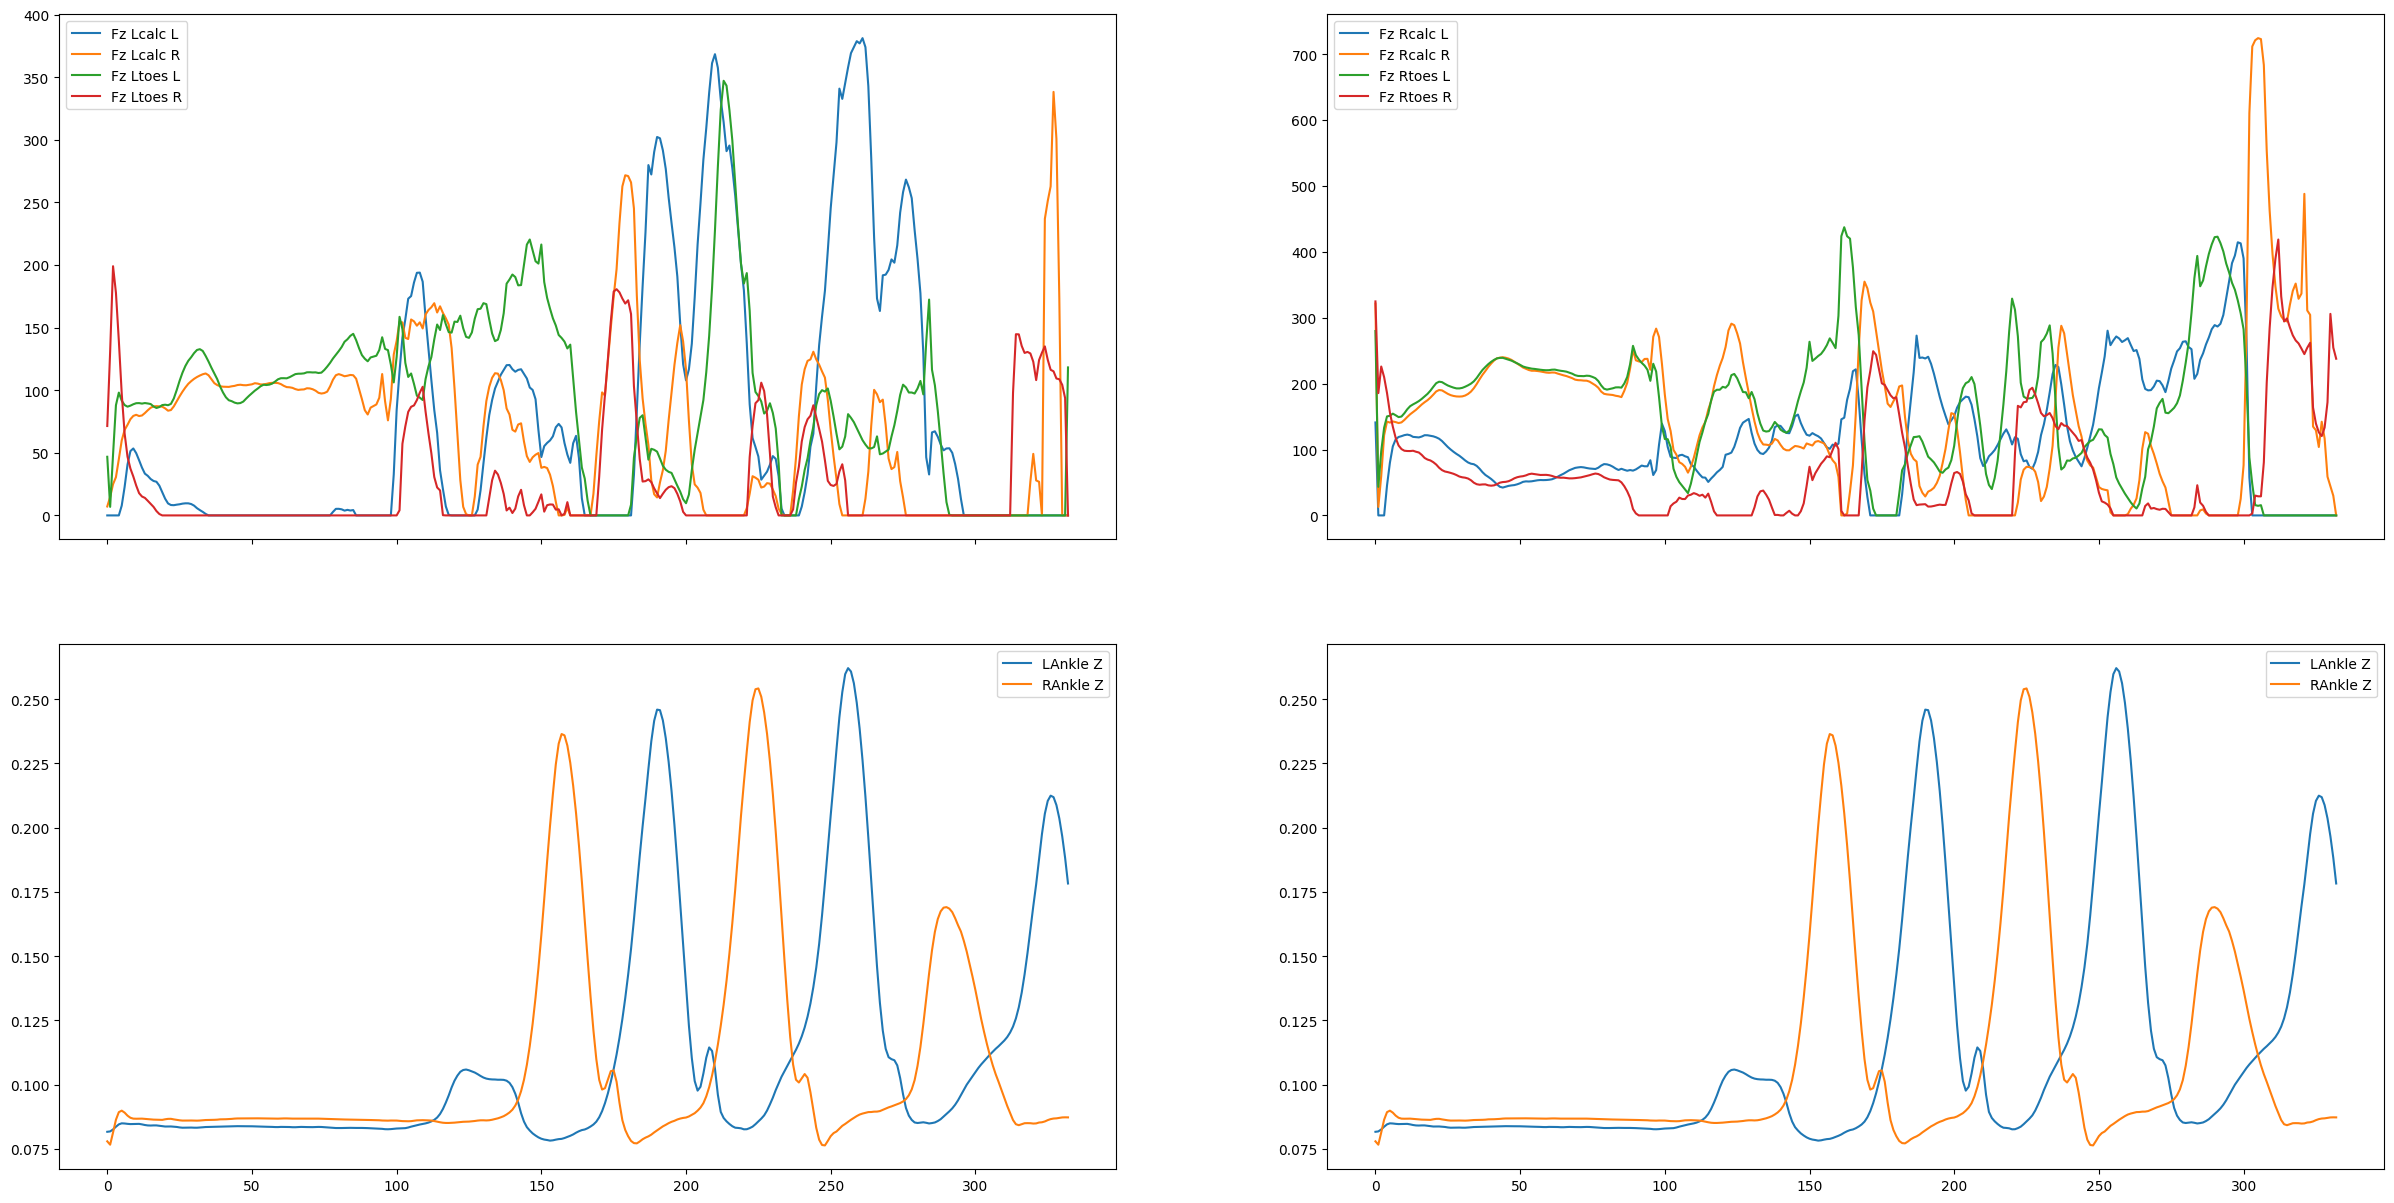

In [338]:
import matplotlib.pyplot as plt
Fc = np.array(Fc)

# plt.plot(Q_dotdot[:,32], label = "kf")
# plt.show()

fig, axs = plt.subplots(2,2,sharex=True, figsize=(30, 15))

axs[0,0].plot(Fc[:,3*0+2],label=f'Fz Lcalc L')
axs[0,0].plot(Fc[:,3*1+2],label=f'Fz Lcalc R')

axs[0,0].plot(Fc[:,3*2+2],label=f'Fz Ltoes L')
axs[0,0].plot(Fc[:,3*3+2],label=f'Fz Ltoes R')

axs[0,1].plot(Fc[:,3*4+2],label=f'Fz Rcalc L')
axs[0,1].plot(Fc[:,3*5+2],label=f'Fz Rcalc R')

axs[0,1].plot(Fc[:,3*6+2],label=f'Fz Rtoes L')
axs[0,1].plot(Fc[:,3*7+2],label=f'Fz Rtoes R')


axs[1,0].plot(target[:Fc.shape[0],32],label=f'LAnkle Z')
axs[1,0].plot(target[:Fc.shape[0],35],label=f'RAnkle Z')
axs[1,1].plot(target[:Fc.shape[0],32],label=f'LAnkle Z')
axs[1,1].plot(target[:Fc.shape[0],35],label=f'RAnkle Z')

axs[0,0].legend()
axs[0,1].legend()
axs[1,0].legend()
axs[1,1].legend()
plt.show()

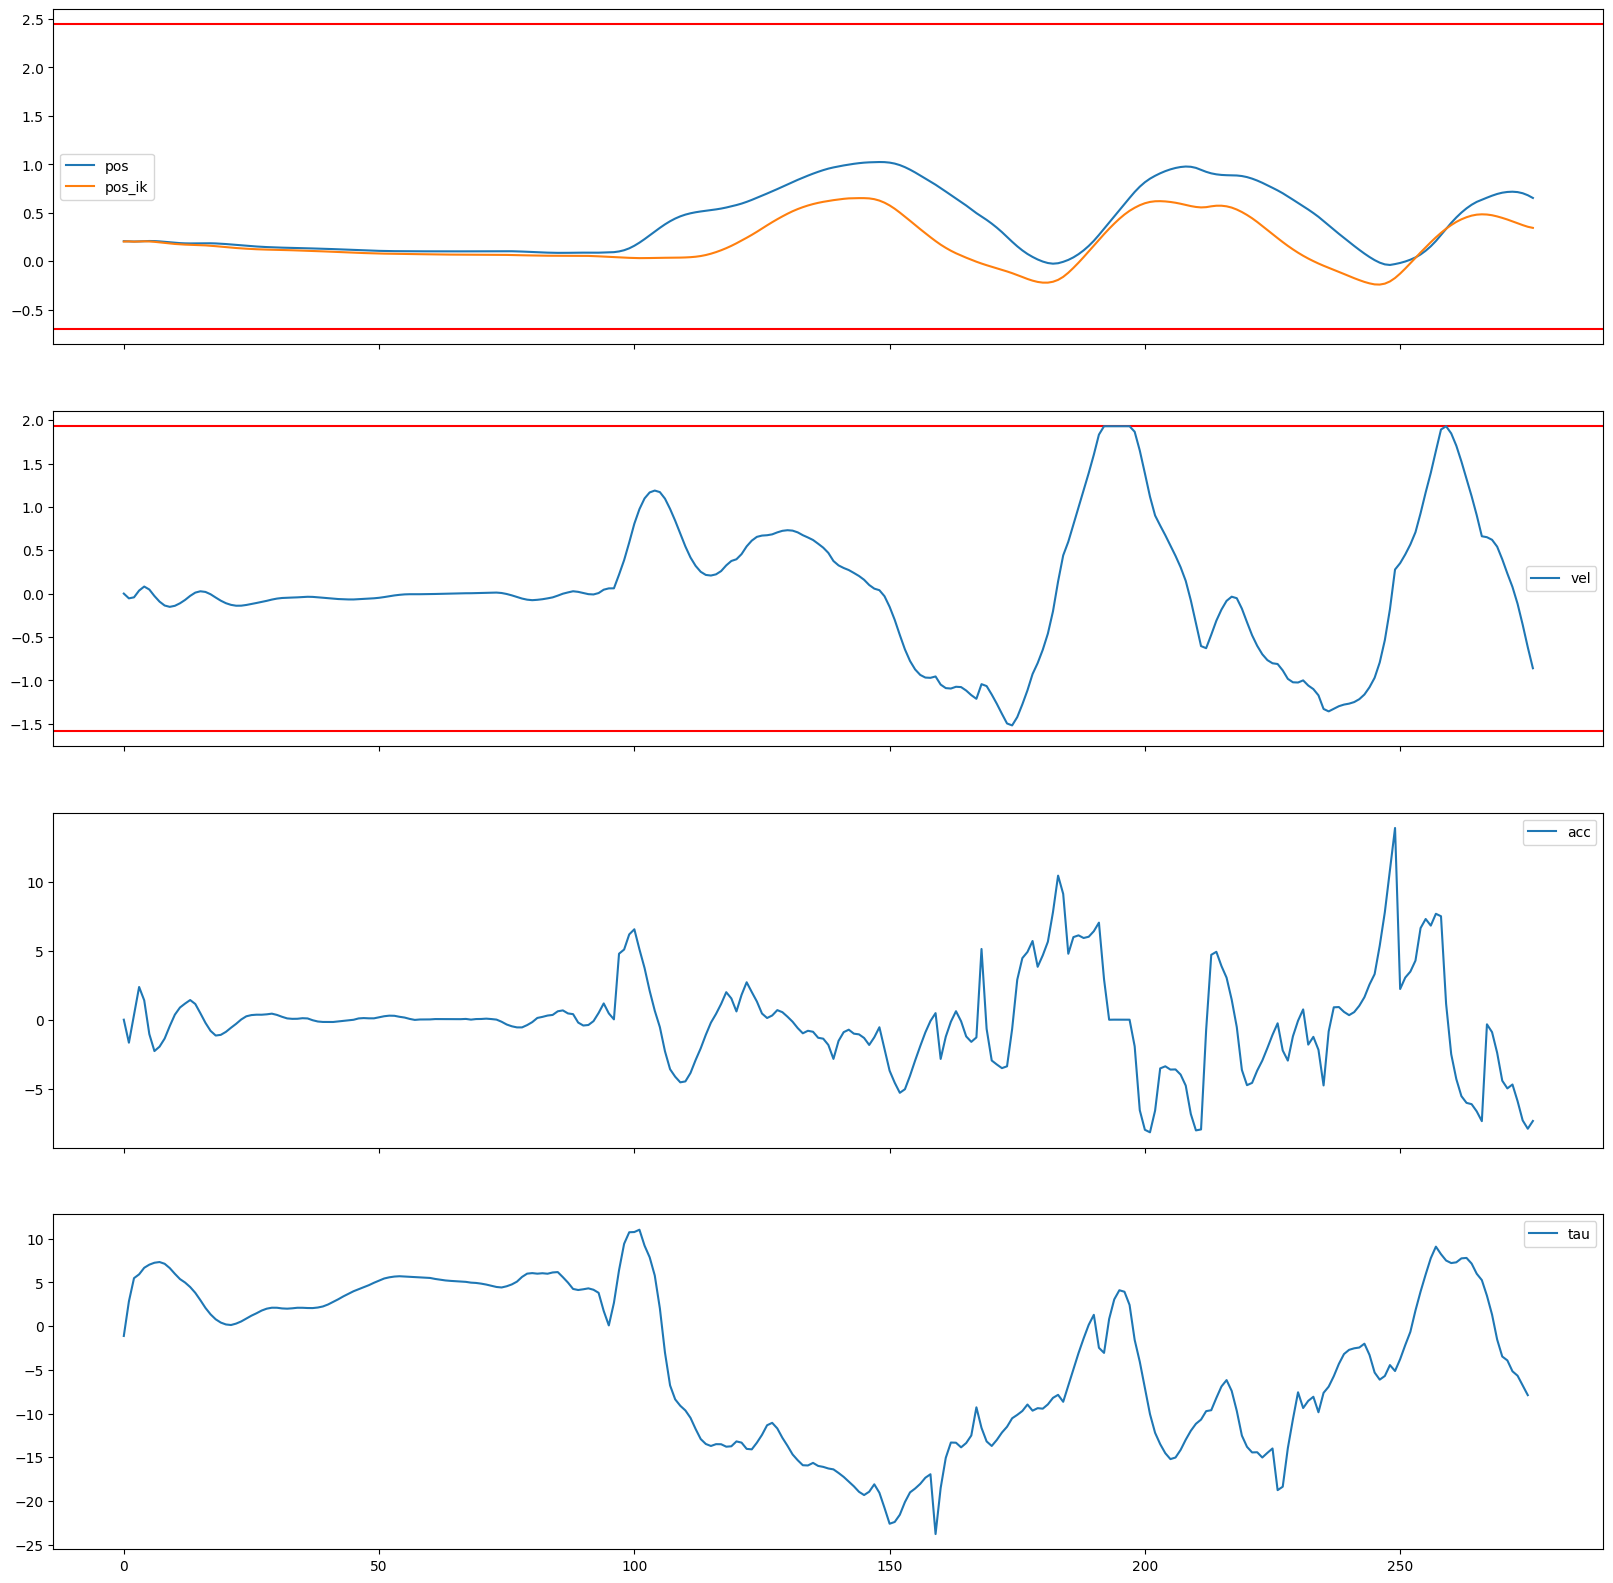

127.0.0.1 - - [04/Mar/2026 18:16:51] code 404, message File not found
127.0.0.1 - - [04/Mar/2026 18:16:51] "GET /v1/health HTTP/1.1" 404 -
127.0.0.1 - - [04/Mar/2026 18:17:21] code 404, message File not found
127.0.0.1 - - [04/Mar/2026 18:17:21] "GET /v1/health HTTP/1.1" 404 -
127.0.0.1 - - [04/Mar/2026 18:17:51] code 404, message File not found
127.0.0.1 - - [04/Mar/2026 18:17:51] "GET /v1/health HTTP/1.1" 404 -
127.0.0.1 - - [04/Mar/2026 18:18:21] code 404, message File not found
127.0.0.1 - - [04/Mar/2026 18:18:21] "GET /v1/health HTTP/1.1" 404 -


In [423]:
results[0].keys()
TAU = [results[i]["tau"] for i in range(len(results)-1)]
TAU = np.array(TAU)

fig, axs = plt.subplots(4,sharex=True, figsize=(20,20))

dof = 6

Q = np.array(Q)
axs[0].plot(Q[:,dof],label=f'pos')
axs[0].axhline(y=s.q_u[dof], color='r', linestyle='-')
axs[0].axhline(y=s.q_l[dof], color='r', linestyle='-')
axs[0].plot(Q_es[:Q.shape[0],dof],label=f'pos_ik')
axs[0].legend()

Q_dot = np.array(Q_dot)
axs[1].axhline(y=s.qdot_u[dof], color='r', linestyle='-')
axs[1].axhline(y=s.qdot_l[dof], color='r', linestyle='-')
axs[1].plot(Q_dot[:,dof],label=f'vel')
axs[1].legend()

Q_dotdot = np.array(Q_dotdot)
axs[2].plot(Q_dotdot[:,dof],label=f'acc')
axs[2].legend()

axs[3].plot(TAU[:,dof-6],label=f'tau')
axs[3].legend()
